In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / 'module').exists() and (p / 'configs').exists():
            return p
    fallback = Path('/N/u/kmluong/BigRed200/regDL-TCIP')
    if fallback.exists():
        return fallback
    raise FileNotFoundError('Cannot find repo root (folder containing module/ and configs/).')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from visualization.model_loader import load_model_from_paths
from module.training.datasets import load_split_arrays
from module.training.masks import extract_bc_rim_from_y, make_rim_mask_like, make_smooth_phi


In [2]:
def load_data_array(data_source: str | Path, split: str = 'test'):
    p = Path(data_source)
    if p.is_dir():
        train, val, test = load_split_arrays(p)
        split = split.lower()
        if split == 'train':
            arr = train
        elif split == 'val':
            if val is None:
                raise ValueError('No val.npy found in this temp dir.')
            arr = val
        elif split == 'test':
            arr = test
        else:
            raise ValueError(f'Invalid split: {split}')
        source_kind = f'temp_dir:{split}'
    else:
        if p.suffix != '.npy':
            raise ValueError(f'DATA_SOURCE must be temp dir or .npy file, got: {p}')
        arr = np.load(p, mmap_mode='r')
        source_kind = 'npy'

    if arr.ndim != 5:
        raise ValueError(f'Data must have shape [N,F,H,W,C], got: {arr.shape}')

    return arr, source_kind


def make_window_tensors(arr, n_idx: int, f_idx: int, step_in: int, device: str):
    N, F, H, W, C = arr.shape
    if not (0 <= n_idx < N):
        raise IndexError(f'SAMPLE_N out of range [0, {N-1}]')
    if not (0 <= f_idx <= F - step_in - 1):
        raise IndexError(
            f'SAMPLE_F out of range [0, {F-step_in-1}] to keep a valid target frame (F={F}, step_in={step_in})'
        )

    x_np = arr[n_idx, f_idx : f_idx + step_in, ...]
    y_np = arr[n_idx, f_idx + step_in, ...]

    # [T,H,W,C] -> [1,T,C,H,W]
    x = torch.from_numpy(np.transpose(x_np, (0, 3, 1, 2)).copy()).float().unsqueeze(0).to(device)
    # [H,W,C] -> [1,C,H,W]
    y = torch.from_numpy(np.transpose(y_np, (2, 0, 1)).copy()).float().unsqueeze(0).to(device)
    return x, y


arr shape: (273, 5, 100, 100, 14)
Z path: /N/slate/kmluong/regDL-TCIP/CMIP6/tmp/test_Z.npy
Z shape: (273, 5, 6)
cm6lat shape: (719, 899)
cm6lon shape: (719, 899)
step_in: 3
frame_ids: [1, 2, 3, 4]
lo: [117.9275 117.075  116.2225 115.37  ]
la: [17.0175 17.425  17.8325 18.24  ]
Map point 0
target lon/lat: 117.92750000000001 17.0175
nearest iy/ix: 144 205
nearest lon/lat: 117.976746 16.998772
crop y0/y1/x0/x1: (94, 194, 155, 255)
center position inside crop: 50 50
Map point 1
target lon/lat: 117.075 17.424999999999997
nearest iy/ix: 148 196
nearest lon/lat: 117.0746 17.381813
crop y0/y1/x0/x1: (98, 198, 146, 246)
center position inside crop: 50 50
Map point 2
target lon/lat: 116.2225 17.8325
nearest iy/ix: 153 187
nearest lon/lat: 116.172455 17.85949
crop y0/y1/x0/x1: (103, 203, 137, 237)
center position inside crop: 50 50
Map point 3
target lon/lat: 115.37 18.24
nearest iy/ix: 157 179
nearest lon/lat: 115.370544 18.240707
crop y0/y1/x0/x1: (107, 207, 129, 229)
center position inside crop

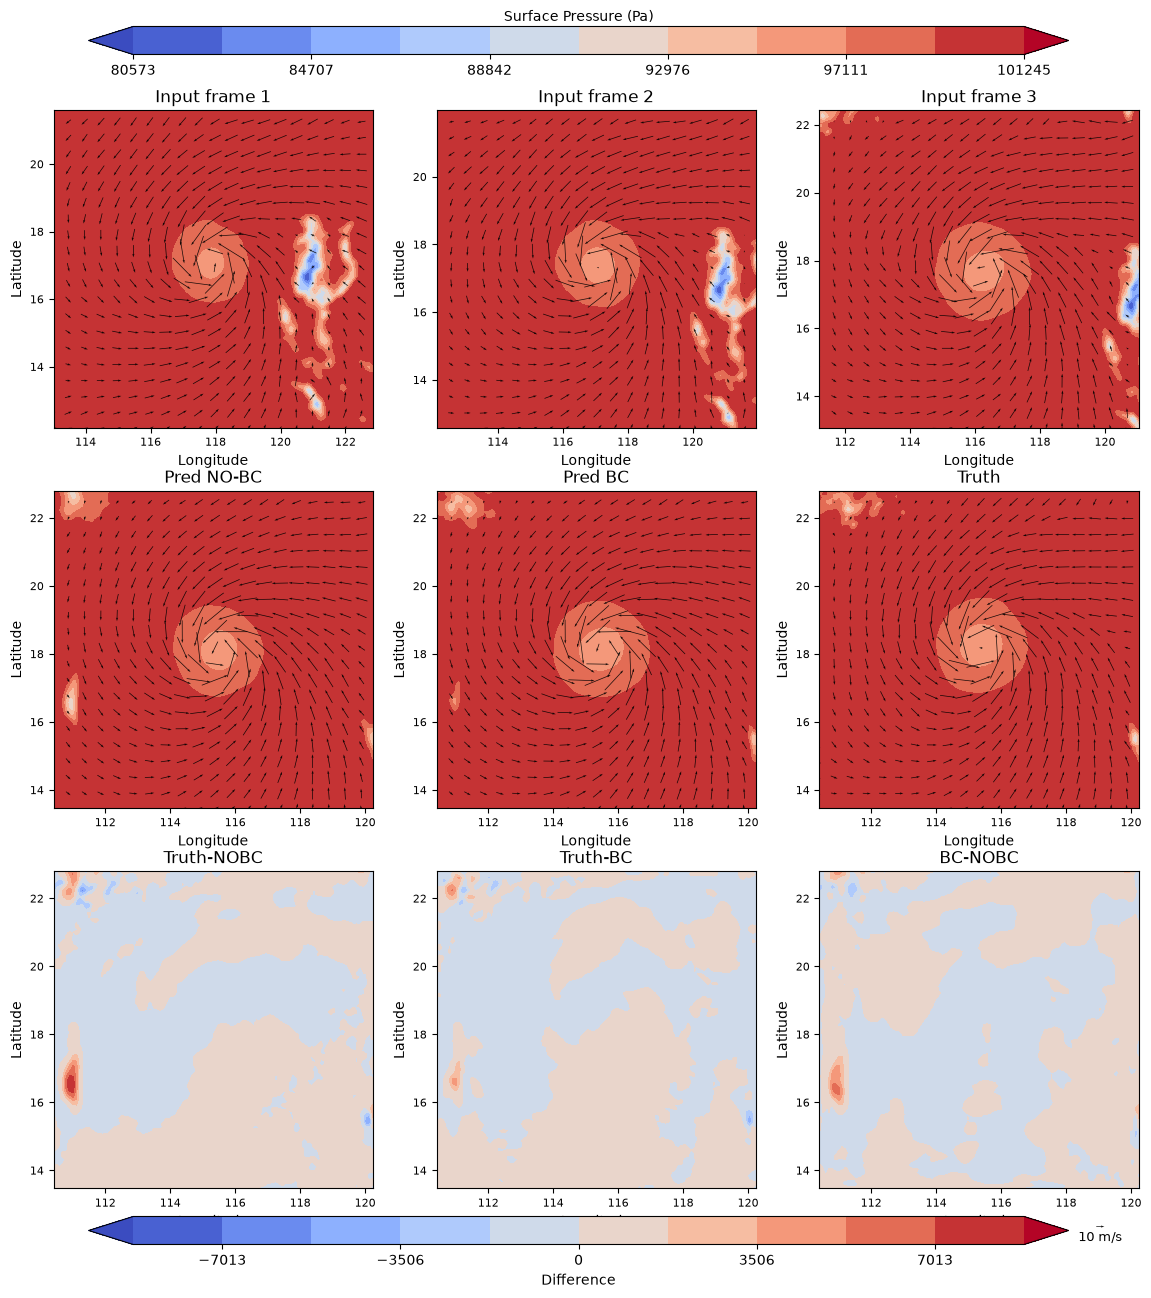

In [3]:
# ===== 12-panel CMIP6 figure + storm-centered coordinate maps from Z =====
# Shape assumption:
#   arr: (sample, frame, h, w, c)
#   Z:   (sample, frame, >=4) = [lon, lat, sinDOY, cosDOY, ...]
#
# In maps  = first 3 frames
# Out map  = last / target frame
# Plot     = scalar CHANNEL_TO_SHOW with U/V quiver overlay from configurable vector channels

from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

from visualization.latlon import (
    extract_centers_from_z,
    extract_latlon_crops_for_track,
    get_extent_from_latlon,
)

# =========================
# User inputs
# =========================
DS = "CMIP6"
DATA_SOURCE = f"/N/slate/kmluong/regDL-TCIP/{DS}/tmp"
LEVEL2_SOURCE = f"/N/slate/kmluong/regDL-TCIP/{DS}/level_2_data"

SPLIT = "test"
SAMPLE_N = 230
SAMPLE_F = 1
CHANNEL_TO_SHOW = 11 # U10m V10m SST LANDMASK U14 V14 U3 V3 T12 QVAPOR5 PHB+PH5 PSFC 0>>11
VECTOR_U_CHANNEL = 0  # U10m
VECTOR_V_CHANNEL = 1  # V10m
VECTOR_LABEL = "U10m/V10m"
QUIVER_STRIDE = 5
QUIVER_SCALE = 40  # None lets matplotlib autoscale; use a number for fixed scaling
QUIVER_WIDTH = 0.0022
REFERENCE_VECTOR_SPEED = 10.0  # m/s
RIM = 1
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CM6_LAT_PATH = f"/N/u/kmluong/BigRed200/Deep-learning-intensity-projection/test_space/cm6lat.npy"
CM6_LON_PATH = f"/N/u/kmluong/BigRed200/Deep-learning-intensity-projection/test_space/cm6lon.npy"

# Try these Z paths in order
Z_CANDIDATES = [
    f"{DATA_SOURCE}/{SPLIT}_Z.npy",
    f"{DATA_SOURCE}/Z.npy",
    f"{LEVEL2_SOURCE}/wrf_tropical_cyclone_track_5f_12v_dataset_Z.npy",
]

MODEL_CONFIG_PATH_BC = f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/AFNO-TCP-BC.json"
MODEL_CHECKPOINT_PATH_BC = f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/trained-AFNO-TCP-BC.pt"

MODEL_CONFIG_PATH_NBC = f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/AFNO-TCP-NO-BC.json"
MODEL_CHECKPOINT_PATH_NBC = f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/trained-AFNO-TCP-NO-BC.pt"


# =========================
# Helpers assumed available: # Yes chatgpt helped most of this
# load_model_from_paths, load_data_array, extract_bc_rim_from_y,
# make_rim_mask_like, make_smooth_phi, make_window_tensors
# =========================
def _run_inference_one_window(model, x, y_true, use_bc: bool, rim: int = 1):
    with torch.no_grad():
        x_in = x
        y_in = y_true

        if getattr(model, "x_scaler", None) is not None:
            x_in = model.x_scaler.norm(x_in)
        if getattr(model, "y_scaler", None) is not None:
            y_in = model.y_scaler.norm(y_in)

        if use_bc:
            b_fill = extract_bc_rim_from_y(y_in, rim=rim)
            bc_mask = make_rim_mask_like(y_in, rim=rim)
            bc_in = torch.cat([b_fill, bc_mask], dim=1)

            y_free = model(x_in, bc_in)

            phi = make_smooth_phi(
                H=y_in.shape[-2],
                W=y_in.shape[-1],
                rim=rim,
                device=y_in.device,
                dtype=y_in.dtype,
            )
            y_pred_norm = phi * y_free + (1.0 - phi) * b_fill
        else:
            y_pred_norm = model(x_in)

        if getattr(model, "y_scaler", None) is not None:
            y_pred = model.y_scaler.denorm(y_pred_norm)
            y_ref = y_true
        else:
            y_pred = y_pred_norm
            y_ref = y_true

    return y_pred, y_ref


def find_existing_path(paths):
    """Return first existing path from candidate list."""
    for p in paths:
        if Path(p).exists():
            return p
    raise FileNotFoundError("No Z file found. Tried:\n" + "\n".join(paths))


# =========================
# Load data
# =========================
arr, _ = load_data_array(DATA_SOURCE, split=SPLIT)
print("arr shape:", arr.shape)

z_path = find_existing_path(Z_CANDIDATES)
Z = np.load(z_path, mmap_mode="r")
print("Z path:", z_path)
print("Z shape:", Z.shape)

cm6lat = np.load(CM6_LAT_PATH)[0]
cm6lon = np.load(CM6_LON_PATH)[0]
print("cm6lat shape:", cm6lat.shape)
print("cm6lon shape:", cm6lon.shape)


# =========================
# Load models
# =========================
model_bc, meta_bc = load_model_from_paths(
    config_path=MODEL_CONFIG_PATH_BC,
    checkpoint_path=MODEL_CHECKPOINT_PATH_BC,
    map_location=DEVICE,
    strict=True,
    eval_mode=True,
)
model_bc = model_bc.to(DEVICE)
step_in_bc = int(meta_bc["config"]["num_times"])

model_nbc, meta_nbc = load_model_from_paths(
    config_path=MODEL_CONFIG_PATH_NBC,
    checkpoint_path=MODEL_CHECKPOINT_PATH_NBC,
    map_location=DEVICE,
    strict=True,
    eval_mode=True,
)
model_nbc = model_nbc.to(DEVICE)
step_in_nbc = int(meta_nbc["config"]["num_times"])

step_in = min(step_in_bc, step_in_nbc)
print("step_in:", step_in)


# =========================
# Build model window
# =========================
x, y_true = make_window_tensors(arr, SAMPLE_N, SAMPLE_F, step_in=step_in, device=DEVICE)

T = x.shape[1]
if T < 3:
    raise ValueError("Need >=3 input frames")

c = int(CHANNEL_TO_SHOW)
u_ch = int(VECTOR_U_CHANNEL)
v_ch = int(VECTOR_V_CHANNEL)
num_channels = int(x.shape[2])
for label, ch in [("CHANNEL_TO_SHOW", c), ("VECTOR_U_CHANNEL", u_ch), ("VECTOR_V_CHANNEL", v_ch)]:
    if not (0 <= ch < num_channels):
        raise IndexError(f"{label}={ch} is out of range for {num_channels} channels")

in_maps = [x[0, t, c].detach().cpu().numpy() for t in range(3)]
in_uv_maps = [
    (
        x[0, t, u_ch].detach().cpu().numpy(),
        x[0, t, v_ch].detach().cpu().numpy(),
    )
    for t in range(3)
]
truth_map = y_true[0, c].detach().cpu().numpy()
truth_uv = (
    y_true[0, u_ch].detach().cpu().numpy(),
    y_true[0, v_ch].detach().cpu().numpy(),
)


# =========================
# Extract lon/lat from Z
# =========================
# Current step2 convention: [lon, lat, sinDOY, cosDOY, ...]
frame_ids = [
    SAMPLE_F,
    SAMPLE_F + 1,
    SAMPLE_F + 2,
    SAMPLE_F + step_in,
]

lo, la = extract_centers_from_z(
    z=Z,
    sample_idx=SAMPLE_N,
    frame_indices=frame_ids,
    feature_order="lon_lat",
)

print("frame_ids:", frame_ids)
print("lo:", lo)
print("la:", la)


# =========================
# Extract 100x100 lat/lon maps
# =========================
crop_result = extract_latlon_crops_for_track(
    lat2d=cm6lat,
    lon2d=cm6lon,
    lon_centers=lo,
    lat_centers=la,
    size=100,
)
lat_crops = crop_result.lat_crops
lon_crops = crop_result.lon_crops
crop_indices = crop_result.crop_indices
center_indices = crop_result.center_indices

for k, (lo_k, la_k, crop_idx, center_idx) in enumerate(zip(lo, la, crop_indices, center_indices)):
    iy, ix = center_idx
    print(f"Map point {k}")
    print("target lon/lat:", lo_k, la_k)
    print("nearest iy/ix:", iy, ix)
    print("nearest lon/lat:", cm6lon[iy, ix], cm6lat[iy, ix])
    print("crop y0/y1/x0/x1:", crop_idx)
    print("center position inside crop:", iy - crop_idx[0], ix - crop_idx[2])

in_extents = [
    get_extent_from_latlon(lat_crops[0], lon_crops[0]),
    get_extent_from_latlon(lat_crops[1], lon_crops[1]),
    get_extent_from_latlon(lat_crops[2], lon_crops[2]),
]
out_extent = get_extent_from_latlon(lat_crops[3], lon_crops[3])

print("Input extents:", in_extents)
print("Output extent:", out_extent)


# =========================
# Predict
# =========================
y_pred_bc, _ = _run_inference_one_window(model_bc, x, y_true, use_bc=True, rim=RIM)
y_pred_nbc, _ = _run_inference_one_window(model_nbc, x, y_true, use_bc=False, rim=RIM)

pred_bc_map = y_pred_bc[0, c].detach().cpu().numpy()
pred_nbc_map = y_pred_nbc[0, c].detach().cpu().numpy()
pred_bc_uv = (
    y_pred_bc[0, u_ch].detach().cpu().numpy(),
    y_pred_bc[0, v_ch].detach().cpu().numpy(),
)
pred_nbc_uv = (
    y_pred_nbc[0, u_ch].detach().cpu().numpy(),
    y_pred_nbc[0, v_ch].detach().cpu().numpy(),
)


# =========================
# Diagnostics
# =========================
d_truth_bc = truth_map - pred_bc_map
d_truth_nbc = truth_map - pred_nbc_map
d_bc_nbc = pred_bc_map - pred_nbc_map
d_truth_nbc_uv = (truth_uv[0] - pred_nbc_uv[0], truth_uv[1] - pred_nbc_uv[1])
d_truth_bc_uv = (truth_uv[0] - pred_bc_uv[0], truth_uv[1] - pred_bc_uv[1])
d_bc_nbc_uv = (pred_bc_uv[0] - pred_nbc_uv[0], pred_bc_uv[1] - pred_nbc_uv[1])


# =========================
# Color scales
# =========================
field_maps = in_maps + [pred_bc_map, pred_nbc_map, truth_map]
vmin = min(float(np.nanmin(m)) for m in field_maps)
vmax = max(float(np.nanmax(m)) for m in field_maps)

diff_maps = [d_truth_bc, d_truth_nbc, d_bc_nbc]
dmax = max(float(np.nanmax(np.abs(m))) for m in diff_maps)
d_vmin, d_vmax = -dmax, dmax
diff_levels = np.linspace(d_vmin, d_vmax, 11)


# =========================
# Plot helpers
# =========================
def _add_uv_quiver(ax, u_map, v_map, extent, color="white"):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    stride = max(1, int(QUIVER_STRIDE))
    h, w = u_map.shape
    xs = np.linspace(extent[0], extent[1], w)
    ys = np.linspace(extent[2], extent[3], h)
    xx, yy = np.meshgrid(xs[::stride], ys[::stride])
    uu = u_map[::stride, ::stride]
    vv = v_map[::stride, ::stride]
    quiver_artist = ax.quiver(
        xx,
        yy,
        uu,
        vv,
        color=color,
        angles="xy",
        scale_units="xy",
        scale=QUIVER_SCALE,
        width=QUIVER_WIDTH,
        alpha=0.9,
        pivot="middle",
        zorder=5,
    )
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    return quiver_artist


# =========================
# Plot
# =========================
fig, axes = plt.subplots(3, 3, figsize=(14, 14), sharex=False, sharey=False)

# Row 1: Inputs
# for j in range(3):
#     im_field = axes[0, j].imshow(
#         in_maps[j],
#         origin="lower",
#         extent=in_extents[j],
#         vmin=vmin,
#         vmax=vmax,
#         cmap="coolwarm",
#         aspect="auto",
#     )
levels = np.linspace(vmin, vmax, 11)
for j in range(3):
    im_field = axes[0, j].contourf(
        in_maps[j],
        levels=levels,
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
        origin="lower",
        extent=in_extents[j],
        extend="both",
    )
    _add_uv_quiver(axes[0, j], in_uv_maps[j][0], in_uv_maps[j][1], in_extents[j], color="k")

# Row 2: Predictions + Truth
# axes[1, 0].imshow(pred_nbc_map, origin="lower", extent=out_extent,
#                   vmin=vmin, vmax=vmax, cmap="viridis", aspect="auto")

# axes[1, 1].imshow(pred_bc_map, origin="lower", extent=out_extent,
#                   vmin=vmin, vmax=vmax, cmap="viridis", aspect="auto")

# axes[1, 2].imshow(truth_map, origin="lower", extent=out_extent,
#                   vmin=vmin, vmax=vmax, cmap="viridis", aspect="auto")

axes[1, 0].contourf(
    pred_nbc_map,
    levels=levels,
    origin="lower",
    extent=out_extent,
    cmap="coolwarm",
    extend="both",
)

axes[1, 1].contourf(
    pred_bc_map,
    levels=levels,
    origin="lower",
    extent=out_extent,
    cmap="coolwarm",
    extend="both",
)

axes[1, 2].contourf(
    truth_map,
    levels=levels,
    origin="lower",
    extent=out_extent,
    cmap="coolwarm",
    extend="both",
)

_add_uv_quiver(axes[1, 0], pred_nbc_uv[0], pred_nbc_uv[1], out_extent, color="k")
_add_uv_quiver(axes[1, 1], pred_bc_uv[0], pred_bc_uv[1], out_extent, color="k")
truth_quiver = _add_uv_quiver(axes[1, 2], truth_uv[0], truth_uv[1], out_extent, color="k")

# Row 3: Diagnostics
im_diff = axes[2, 0].contourf(
    d_truth_nbc, levels=diff_levels, origin="lower", extent=out_extent,
    vmin=d_vmin, vmax=d_vmax, cmap="coolwarm", extend="both",
)

axes[2, 1].contourf(
    d_truth_bc, levels=diff_levels, origin="lower", extent=out_extent,
    vmin=d_vmin, vmax=d_vmax, cmap="coolwarm", extend="both",
)

axes[2, 2].contourf(
    d_bc_nbc, levels=diff_levels, origin="lower", extent=out_extent,
    vmin=d_vmin, vmax=d_vmax, cmap="coolwarm", extend="both",
)


# =========================
# Titles
# =========================
titles = [
    ["Input frame 1", "Input frame 2", "Input frame 3"],
    ["Pred NO-BC", "Pred BC", "Truth"],
    ["Truth-NOBC", "Truth-BC", "BC-NOBC"],
]

for i in range(3):
    for j in range(3):
        axes[i, j].set_title(titles[i][j])
        axes[i, j].set_xlabel("Longitude")
        axes[i, j].set_ylabel("Latitude")
        axes[i, j].tick_params(labelsize=8)

# =========================
# TOP COLORBAR 
# =========================
cbar_ax_top = fig.add_axes([0.15, 0.92, 0.7, 0.02])  
# [left, bottom, width, height] (figure coords)

cbar_top = fig.colorbar(
    im_field,
    cax=cbar_ax_top,
    orientation="horizontal"
)
cbar_top.set_label("Surface Pressure (Pa)")
cbar_top.ax.xaxis.set_label_position('top')


# =========================
# BOTTOM COLORBAR
# =========================
cbar_ax_bottom = fig.add_axes([0.15, 0.07, 0.7, 0.02])

cbar_bottom = fig.colorbar(
    im_diff,
    cax=cbar_ax_bottom,
    orientation="horizontal"
)
cbar_bottom.set_label("Difference")

# Reference vector uses the Truth-panel Quiver scale and transform.
axes[1, 2].quiverkey(
    truth_quiver,
    X=0.88,
    Y=-1.32,
    U=REFERENCE_VECTOR_SPEED,
    label=f"{REFERENCE_VECTOR_SPEED:g} m/s",
    labelpos="S",
    labelsep=0.05,
    coordinates="axes",
    fontproperties={"size": 9},
)

plt.savefig("visualization_cmip6_map.png", dpi=200, bbox_inches="tight")
plt.show()